In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/churn-modellingcsv/Churn_Modelling.csv


In [3]:
df=pd.read_csv('/kaggle/input/churn-modellingcsv/Churn_Modelling.csv')

In [7]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [8]:
print(df.shape)

(10000, 14)


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [11]:
df.duplicated().sum()

np.int64(0)

In [13]:
df['Exited'].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

In [15]:
df['Geography'].value_counts()

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

In [16]:
df['Gender'].value_counts()

Gender
Male      5457
Female    4543
Name: count, dtype: int64

In [19]:
df.drop(columns=['RowNumber','CustomerId','Surname'],inplace=True)

In [20]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [25]:
df.shape

(10000, 11)

In [26]:
df=pd.get_dummies(df,columns=['Geography','Gender'],drop_first=True)

In [27]:
df.shape

(10000, 12)

In [29]:
X=df.drop(columns=['Exited'])
y=df['Exited']
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=1)

In [32]:
X_train.shape

(8000, 11)

In [33]:
y_train.shape

(8000,)

In [34]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [35]:
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled =scaler.transform(X_test)

In [36]:
X_train_scaled


array([[-0.23082038, -0.94449979, -0.70174202, ...,  1.71490137,
        -0.57273139,  0.91509065],
       [-0.25150912, -0.94449979, -0.35520275, ..., -0.58312392,
        -0.57273139, -1.09278791],
       [-0.3963303 ,  0.77498705,  0.33787579, ...,  1.71490137,
        -0.57273139, -1.09278791],
       ...,
       [ 0.22433188,  0.58393295,  1.3774936 , ..., -0.58312392,
        -0.57273139, -1.09278791],
       [ 0.13123255,  0.01077067,  1.03095433, ..., -0.58312392,
        -0.57273139, -1.09278791],
       [ 1.1656695 ,  0.29735181,  0.33787579, ...,  1.71490137,
        -0.57273139,  0.91509065]])

In [37]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

2026-02-08 06:47:53.161519: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1770533273.490551      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1770533273.576537      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1770533274.349256      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770533274.349318      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770533274.349321      55 computation_placer.cc:177] computation placer alr

In [65]:
model = Sequential()

model.add(Dense(11,activation='relu',input_dim=11))
model.add(Dense(11,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

In [66]:
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            12 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 276 (1.08 KB)

 Trainable params: 276 (1.08 KB)

 Non-trainable params: 0 (0.00 B)

In [78]:
model.compile(loss='binary_crossentropy',optimizer='Adam')

In [79]:
model.compile(loss='binary_crossentropy',optimizer='Adam',metrics=['accuracy'])

In [80]:
history=model.fit(X_train_scaled,y_train,epochs=100,validation_split=0.2)

Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8699 - loss: 0.3126 - val_accuracy: 0.8531 - val_loss: 0.3387
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8730 - loss: 0.3185 - val_accuracy: 0.8544 - val_loss: 0.3387
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8716 - loss: 0.3024 - val_accuracy: 0.8550 - val_loss: 0.3393
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8647 - loss: 0.3198 - val_accuracy: 0.8544 - val_loss: 0.3393
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8700 - loss: 0.3083 - val_accuracy: 0.8550 - val_loss: 0.3403
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8689 - loss: 0.3104 - val_accuracy: 0.8531 - val_loss: 0.3409
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8717 - loss: 0.3102 - val_accuracy: 0.8531 - val_loss: 0.3408
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8653 - loss: 0.3120 - val_accu

In [81]:
model.layers[0].get_weights()

[array([[-1.44341201e-01,  1.09459393e-01,  3.72372009e-02,
         -6.69334754e-02,  1.91659406e-02,  1.04266837e-01,
          1.48583874e-01,  1.51848244e-02, -1.65854171e-01,
         -3.25533235e-03, -1.91501305e-01],
        [ 2.88747693e-03, -6.27138019e-02,  8.79979506e-02,
          7.28992879e-01, -3.27772915e-01,  4.55386132e-01,
          5.92926629e-02,  1.42452908e+00,  7.76925862e-01,
         -2.77060986e-01,  4.27552015e-02],
        [ 1.21616103e-01, -2.71183848e-01, -1.48445740e-01,
          9.46116149e-02, -3.42836797e-01,  9.63856801e-02,
         -2.03891490e-02, -4.03330661e-03,  6.20236248e-02,
          4.78261933e-02,  2.38388449e-01],
        [ 3.68166566e-01,  3.82239819e-02,  1.22186208e+00,
         -6.60589337e-02,  1.07550705e-02, -7.87880551e-03,
          7.16927111e-01, -3.75850536e-02,  4.25048769e-01,
          4.77067679e-02, -4.16961640e-01],
        [-5.54705679e-01, -1.93390757e-01,  1.17114139e+00,
         -1.03303254e+00, -2.10009471e-01,  

In [84]:
model.layers[1].get_weights()

[array([[ 0.10281581, -0.33841047,  0.12258821, -0.6926111 , -0.61609584,
          0.07799836, -0.02380003,  0.09122694,  0.19881944, -0.67586136,
         -0.19613588],
        [-0.4278267 , -0.67575204, -0.13697779,  0.35552529, -0.71533734,
         -0.06495031, -0.00748632,  0.15145564,  0.347135  ,  0.0803161 ,
          0.01539594],
        [-0.21199459, -0.29252663, -1.2208277 ,  0.41627097,  0.934913  ,
         -1.5028063 ,  0.4352576 , -1.0000757 ,  0.39943346,  0.287841  ,
          0.5829643 ],
        [ 0.5298414 ,  0.36890584, -0.18663567, -0.24398205,  0.07114257,
         -0.20968597, -0.04803346, -0.4924097 ,  0.02315999,  0.9382583 ,
          0.18717033],
        [ 0.53436816, -0.953178  ,  0.02021511,  0.0724766 , -0.80255526,
         -0.23706546, -0.91117305, -0.14156513,  0.24102865,  0.27029264,
          0.08638071],
        [ 0.26380444, -0.53962344,  0.24765097,  0.36128357, -0.5415575 ,
         -0.54853904, -0.3855759 ,  0.66010386,  0.02434441,  0.4737252

In [85]:
y_log=model.predict(X_test_scaled)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [86]:
y_pred=np.where(y_log>0.5,1,0)

In [87]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.8595

In [88]:
import matplotlib.pyplot as plt 

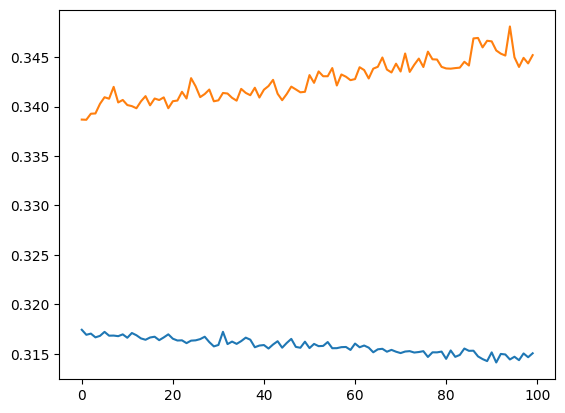

In [91]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])